# EDA de reclamos CFPB

Este notebook documenta el análisis exploratorio paso a paso. Cada etapa se revisa antes de continuar.

## E0 — Verificar el archivo raw

**Pregunta:** ¿Estamos trabajando con el archivo correcto y cuál es su estructura física?

En este paso no transformamos datos ni cargamos el corpus completo en memoria. Solo revisamos el archivo, sus metadatos Parquet, su esquema y cinco registros protegidos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import display

### 1. Localizar el raw y su puntero DVC

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet"
DVC_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet.dvc"

assert RAW_PATH.exists(), f"No se encontró el raw: {RAW_PATH}"
assert DVC_PATH.exists(), f"No se encontró el puntero DVC: {DVC_PATH}"

dvc_lines = DVC_PATH.read_text(encoding="utf-8").splitlines()
dvc_md5 = next(line.split(":", 1)[1].strip() for line in dvc_lines if line.strip().startswith("- md5:"))

display(pd.DataFrame({
    "campo": ["archivo", "tamaño físico", "MD5 registrado por DVC"],
    "valor": [RAW_PATH.name, f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB", dvc_md5],
}))

,campo,valor
0,archivo,cfpb_reclamos_narrativa.parquet
1,tamaño físico,1.51 GiB
2,MD5 registrado por DVC,68f4560aca0967779f118e8225e72c26


### 2. Leer metadatos Parquet

Los metadatos permiten contar filas y columnas sin cargar todas las narrativas.

In [3]:
parquet = pq.ParquetFile(RAW_PATH)
metadata = parquet.metadata
logical_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))

summary = pd.DataFrame({
    "medida": [
        "filas",
        "columnas",
        "grupos de filas",
        "tamaño físico",
        "tamaño lógico Parquet",
        "creado por",
    ],
    "valor": [
        f"{metadata.num_rows:,}",
        metadata.num_columns,
        metadata.num_row_groups,
        f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB",
        f"{logical_bytes / 1024**3:.2f} GiB",
        metadata.created_by,
    ],
})

assert metadata.num_rows == 3_837_184
assert metadata.num_columns == 16
display(summary)

,medida,valor
0,filas,"3,837,184"
1,columnas,16
2,grupos de filas,83
3,tamaño físico,1.51 GiB
4,tamaño lógico Parquet,3.73 GiB
5,creado por,parquet-cpp-arrow version 24.0.0


### 3. Revisar el esquema físico

In [4]:
schema = parquet.schema_arrow
schema_table = pd.DataFrame({
    "columna": [field.name for field in schema],
    "tipo parquet": [str(field.type) for field in schema],
    "permite nulos": [field.nullable for field in schema],
})
display(schema_table)

,columna,tipo parquet,permite nulos
0,Date received,large_string,True
1,Product,large_string,True
2,Sub-product,large_string,True
3,Issue,large_string,True
4,Sub-issue,large_string,True
5,Consumer complaint narrative,large_string,True
6,Company public response,large_string,True
7,Company,large_string,True
8,State,large_string,True
9,ZIP code,large_string,True


### 4. Verificar cinco registros sin publicar narrativas

La narrativa se reemplaza por su cantidad de caracteres para no guardar texto de consumidores en la salida del notebook.

In [5]:
sample = ds.dataset(RAW_PATH, format="parquet").head(5).to_pandas()
narrative_column = "Consumer complaint narrative"
sample[narrative_column] = sample[narrative_column].map(
    lambda text: f"<narrativa: {len(text):,} caracteres>" if isinstance(text, str) else "<sin narrativa>"
)
display(sample.T)

,0,1,2,3,4
Date received,2023-04-21,2023-07-13,2023-06-27,2024-05-06,2025-06-25
Product,Checking or savings account,"Money transfer, virtual currency, or money ser...",Mortgage,Debt collection,Student loan
Sub-product,Checking account,International money transfer,Other type of mortgage,Auto debt,Federal student loan servicing
Issue,Managing an account,Fraud or scam,Trouble during payment process,Took or threatened to take negative or legal a...,Dealing with your lender or servicer
Sub-issue,Deposits and withdrawals,NaN,NaN,Seized or attempted to seize your property,Trouble with how payments are being handled
Consumer complaint narrative,"<narrativa: 1,094 caracteres>","<narrativa: 1,392 caracteres>","<narrativa: 10,703 caracteres>",<narrativa: 779 caracteres>,"<narrativa: 1,206 caracteres>"
Company public response,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,NaN,NaN
Company,U.S. BANCORP,"BANK OF AMERICA, NATIONAL ASSOCIATION",Specialized Loan Servicing Holdings LLC,TOYOTA MOTOR CREDIT CORPORATION,MOHELA
State,CA,GA,CA,CA,MA
ZIP code,91362,30032,94954,94112,02360


## Resultado de E0

- El archivo raw y su puntero DVC están disponibles.
- El archivo contiene **3,837,184 filas y 16 columnas**.
- La estructura puede inspeccionarse sin cargar el corpus completo en memoria.
- E0 no modifica el raw ni genera datos derivados.
- El siguiente paso, sujeto a aprobación, es **E1: revisar tipos, nulos, dominios y ejemplos de cada columna**.

## E1 — Revisar tipos, nulos y dominios

**Pregunta:** ¿Qué representa cada columna y qué tan completa está?

Primero contamos nulos desde los metadatos Parquet. Luego revisamos los valores más frecuentes de las columnas categóricas. La narrativa, las fechas y el identificador se estudiarán en sus pasos específicos.

### 1. Nulos por columna

In [6]:
null_rows = []
for column_index, field in enumerate(schema):
    statistics = [
        metadata.row_group(row_group).column(column_index).statistics
        for row_group in range(metadata.num_row_groups)
    ]
    assert all(stat is not None and stat.null_count is not None for stat in statistics)
    null_count = sum(stat.null_count for stat in statistics)
    null_rows.append({
        "columna": field.name,
        "nulos": null_count,
        "porcentaje": 100 * null_count / metadata.num_rows,
    })

null_table = pd.DataFrame(null_rows).sort_values("nulos", ascending=False, ignore_index=True)
null_display = null_table.copy()
null_display["nulos"] = null_display["nulos"].map("{:,}".format)
null_display["porcentaje"] = null_display["porcentaje"].map("{:.2f}%".format)
display(null_display)

,columna,nulos,porcentaje
0,Tags,"3,469,552",90.42%
1,Company public response,"1,795,421",46.79%
2,Sub-issue,"335,268",8.74%
3,Sub-product,"52,205",1.36%
4,State,"13,718",0.36%
5,ZIP code,290,0.01%
6,Company response to consumer,9,0.00%
7,Date received,0,0.00%
8,Company,0,0.00%
9,Consumer complaint narrative,0,0.00%


### 2. Tipo físico y significado esperado

El Parquet guarda las 16 columnas como texto. Eso no significa que deban conservar ese tipo después del EDA.

In [7]:
semantic_types = {
    "Date received": "fecha",
    "Product": "categoría",
    "Sub-product": "categoría",
    "Issue": "categoría",
    "Sub-issue": "categoría",
    "Consumer complaint narrative": "texto libre",
    "Company public response": "categoría",
    "Company": "categoría",
    "State": "categoría geográfica",
    "ZIP code": "identificador geográfico",
    "Tags": "categoría",
    "Submitted via": "categoría",
    "Date sent to company": "fecha",
    "Company response to consumer": "categoría / posible objetivo",
    "Timely response?": "binaria / posible objetivo",
    "Complaint ID": "identificador",
}

type_table = schema_table.copy()
type_table["significado esperado"] = type_table["columna"].map(semantic_types)
display(type_table)

,columna,tipo parquet,permite nulos,significado esperado
0,Date received,large_string,True,fecha
1,Product,large_string,True,categoría
2,Sub-product,large_string,True,categoría
3,Issue,large_string,True,categoría
4,Sub-issue,large_string,True,categoría
5,Consumer complaint narrative,large_string,True,texto libre
6,Company public response,large_string,True,categoría
7,Company,large_string,True,categoría
8,State,large_string,True,categoría geográfica
9,ZIP code,large_string,True,identificador geográfico


### 3. Dominios categóricos

Se cuentan valores distintos y se muestran los tres más frecuentes. Cada columna se lee por separado para mantener bajo el uso de memoria.

In [8]:
category_columns = [
    "Product", "Sub-product", "Issue", "Sub-issue",
    "Company public response", "Company", "State", "ZIP code",
    "Tags", "Submitted via", "Company response to consumer",
    "Timely response?",
]

domain_rows = []
for column in category_columns:
    values = pq.read_table(RAW_PATH, columns=[column]).column(0)
    counts = sorted(
        pc.value_counts(values).to_pylist(),
        key=lambda row: row["counts"],
        reverse=True,
    )
    non_null_counts = [row for row in counts if row["values"] is not None]
    top_three = " | ".join(
        f"{str(row['values'])[:45]} ({row['counts']:,})"
        for row in non_null_counts[:3]
    )
    domain_rows.append({
        "columna": column,
        "valores distintos": len(non_null_counts),
        "tres más frecuentes": top_three,
    })

domain_table = pd.DataFrame(domain_rows)
display(domain_table)

,columna,valores distintos,tres más frecuentes
0,Product,21,Credit reporting or other personal consumer r ...
1,Sub-product,85,"Credit reporting (2,457,199) | General-purpose..."
2,Issue,173,"Incorrect information on your report (1,205,00..."
3,Sub-issue,266,"Information belongs to someone else (697,613) ..."
4,Company public response,11,Company has responded to the consumer and the ...
5,Company,6831,"EQUIFAX, INC. (817,318) | TRANSUNION INTERMEDI..."
6,State,63,"TX (485,539) | FL (458,316) | CA (409,800)"
7,ZIP code,6938,"XXXXX (72,506) | 604XX (12,261) | 770XX (11,573)"
8,Tags,3,"Servicemember (240,176) | Older American (98,6..."
9,Submitted via,1,"Web (3,837,184)"


## Resultado de E1

- El archivo almacena las 16 columnas como texto, aunque fechas, categorías e identificadores tienen significados diferentes.
- Los mayores faltantes están en `Tags` (90.42%), `Company public response` (46.79%) y `Sub-issue` (8.74%). No los rellenaremos sin justificar primero qué significa su ausencia.
- `Submitted via` contiene únicamente `Web`; por tanto, no aporta variación en este dataset.
- Hay 21 productos, 173 issues y 6,831 empresas. Su frecuencia y concentración se estudiarán en E3.
- `Company response to consumer` y `Timely response?` ocurren después de ingresar el reclamo: pueden ser objetivos, pero no features de entrada.
- E1 describe el raw; todavía no cambia tipos ni rellena valores.
- El siguiente paso, sujeto a aprobación, es **E2: cobertura y volumen temporal**.

## E2 — Cobertura y volumen temporal

**Pregunta:** ¿Qué periodo cubren los reclamos y cómo cambia su volumen con el tiempo?

Solo se leen `Date received` y `Date sent to company`. El análisis temporal usa la fecha de recepción.

### 1. Convertir y validar las fechas

In [9]:
date_columns = ["Date received", "Date sent to company"]
date_text = pd.read_parquet(RAW_PATH, columns=date_columns, dtype_backend="pyarrow")
dates = date_text.apply(pd.to_datetime, format="%Y-%m-%d", errors="coerce")

date_quality = pd.DataFrame({
    "columna": date_columns,
    "mínimo": [dates[column].min().date() for column in date_columns],
    "máximo": [dates[column].max().date() for column in date_columns],
    "texto nulo": [date_text[column].isna().sum() for column in date_columns],
    "fecha inválida": [
        (dates[column].isna() & date_text[column].notna()).sum()
        for column in date_columns
    ],
})
del date_text
display(date_quality)

,columna,mínimo,máximo,texto nulo,fecha inválida
0,Date received,2015-03-19,2026-07-27,0,0
1,Date sent to company,2015-03-19,2026-08-13,0,0


### 2. Reclamos por año

El primer y el último año pueden estar incompletos dentro del archivo, por lo que no deben compararse directamente con años completos.

In [10]:
received = dates["Date received"]
annual_counts = received.dt.year.value_counts().sort_index()
annual_table = annual_counts.rename_axis("año").reset_index(name="reclamos")
annual_table["porcentaje"] = 100 * annual_table["reclamos"] / len(received)
annual_table["cobertura en el archivo"] = "año completo"
annual_table.loc[annual_table["año"] == received.min().year, "cobertura en el archivo"] = (
    f"desde {received.min().date()}"
)
annual_table.loc[annual_table["año"] == received.max().year, "cobertura en el archivo"] = (
    f"hasta {received.max().date()}"
)
annual_display = annual_table.copy()
annual_display["reclamos"] = annual_display["reclamos"].map("{:,}".format)
annual_display["porcentaje"] = annual_display["porcentaje"].map("{:.2f}%".format)
display(annual_display)

,año,reclamos,porcentaje,cobertura en el archivo
0,2015,"54,723",1.43%,desde 2015-03-19
1,2016,"77,766",2.03%,año completo
2,2017,"115,311",3.01%,año completo
3,2018,"118,393",3.09%,año completo
4,2019,"124,843",3.25%,año completo
5,2020,"174,297",4.54%,año completo
6,2021,"203,570",5.31%,año completo
7,2022,"337,273",8.79%,año completo
8,2023,"487,410",12.70%,año completo
9,2024,"814,384",21.22%,año completo


### 3. Reclamos por mes

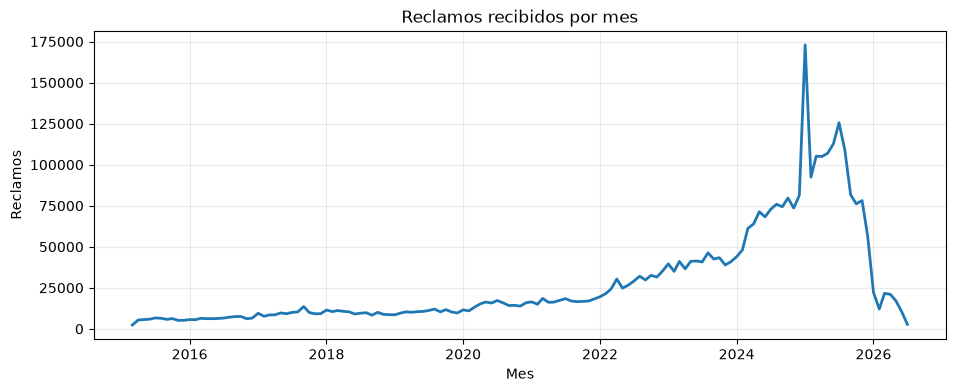

,mes,reclamos
0,2025-08,"108,868"
1,2025-09,"81,659"
2,2025-10,"76,162"
3,2025-11,"78,131"
4,2025-12,"56,510"
5,2026-01,"22,211"
6,2026-02,"12,100"
7,2026-03,"21,603"
8,2026-04,"21,024"
9,2026-05,"17,040"


In [11]:
monthly_counts = received.dt.to_period("M").value_counts().sort_index()
monthly_dates = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_dates, monthly_counts.values, linewidth=2)
ax.set(title="Reclamos recibidos por mes", xlabel="Mes", ylabel="Reclamos")
ax.grid(alpha=0.25)
plt.show()

recent_months = monthly_counts.tail(12).rename_axis("mes").reset_index(name="reclamos")
recent_months["mes"] = recent_months["mes"].astype(str)
recent_months["reclamos"] = recent_months["reclamos"].map("{:,}".format)
display(recent_months)

### 4. Tiempo hasta el envío a la empresa

Este intervalo mide cuándo CFPB envió el reclamo a la empresa. **No es tiempo de resolución ni permite medir el plazo bancario de 15 días hábiles.**

In [12]:
forwarding_days = (dates["Date sent to company"] - received).dt.days
forwarding_summary = pd.DataFrame({
    "medida": [
        "mismo día", "mediana", "percentil 95",
        "máximo", "intervalos negativos",
    ],
    "valor": [
        f"{(forwarding_days == 0).mean():.2%}",
        f"{forwarding_days.median():.0f} días",
        f"{forwarding_days.quantile(0.95):.0f} días",
        f"{forwarding_days.max():.0f} días",
        f"{(forwarding_days < 0).sum():,}",
    ],
})
display(forwarding_summary)

,medida,valor
0,mismo día,93.26%
1,mediana,0 días
2,percentil 95,2 días
3,máximo,1748 días
4,intervalos negativos,0


## Resultado de E2

- Las dos columnas se convierten a fecha sin valores inválidos ni faltantes.
- `Date received` cubre desde 2015-03-19 hasta 2026-07-27; 2015 y 2026 son años parciales dentro del archivo.
- El volumen crece fuertemente: 2025 concentra 1,222,056 reclamos (31.85% del corpus). Por eso una división aleatoria mezclaría periodos diferentes.
- La reducción observada en 2026 puede deberse a cobertura o retraso de publicación; no demuestra una caída real.
- CFPB envió 93.26% de los reclamos a la empresa el mismo día y 95% en dos días o menos, pero existe un máximo atípico de 1,748 días.
- `Date sent to company` no representa cierre ni resolución y no permite medir el plazo bancario de 15 días.
- La fecha principal para ordenar y dividir los reclamos será `Date received`; los cortes concretos se decidirán en E8.
- El siguiente paso, sujeto a aprobación, es **E3: productos, issues, empresas y canal de envío**.